## UI from windstress

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd

In [2]:
dsi = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})
dsi

<xarray.Dataset> Size: 891MB
Dimensions:     (xi_rho: 602, xi_u: 601, eta_rho: 542, eta_v: 541, s_rho: 32,
                 s_w: 33, time: 1, auxil: 4)
Coordinates: (12/13)
  * xi_rho      (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * xi_u        (xi_u) float64 5kB 1.5 2.5 3.5 4.5 ... 598.5 599.5 600.5 601.5
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 540.0 541.0 542.0
  * eta_v       (eta_v) float64 4kB 1.5 2.5 3.5 4.5 ... 538.5 539.5 540.5 541.5
  * s_rho       (s_rho) float64 256B -0.9844 -0.9531 ... -0.04688 -0.01562
  * s_w         (s_w) float64 264B -1.0 -0.9688 -0.9375 ... -0.0625 -0.03125 0.0
    ...          ...
    lat_rho     (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(542, 602), meta=np.ndarray>
    lon_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lat_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lon_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
    lat_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
  * time        (time) float32 4B 1.339e+06
Dimensions without coordinates: auxil
Data variables: (12/54)
    spherical   |S1 1B ...
    xl          float64 8B ...
    el          float64 8B ...
    Vtransform  float64 8B ...
    sc_r        (s_rho) float64 256B dask.array<chunksize=(32,), meta=np.ndarray>
    sc_w        (s_w) float64 264B dask.array<chunksize=(33,), meta=np.ndarray>
    ...          ...
    swflux      (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    radsw       (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_rlw   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_lat   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_sen   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    hel         (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
Attributes: (12/57)
    type:           ROMS restart file
    title:          Peru UW Interannual Run
    date:           
    rst_file:       croco_rst.nc
    his_file:       croco_his.nc
    avg_file:       croco_avg.nc
    ...             ...
    gamma2_expl:    Slipperiness parameter
    x_sponge:       0.0
    v_sponge:       0.0
    sponge_expl:    Sponge parameters : extent (m) & viscosity (m2.s-1)
    SRCS:           main.F step.F read_inp.F timers_roms.F init_scalars.F ini...
    CPP-options:    REGIONAL PERU_UW MPI OBC_WEST OBC_NORTH OBC_SOUTH BIOLOGY...

In [3]:
ds_uwnd = xr.open_mfdataset('../../NHCS/hincast_1980-2015/extracted_*.nc', 
                     chunks = {'time':100}).sustr
ds_uwnd

<xarray.DataArray 'sustr' (time: 432, eta_rho: 542, xi_u: 601)> Size: 563MB
dask.array<concatenate, shape=(432, 542, 601), dtype=float32, chunksize=(1, 542, 601), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) float32 2kB 1.339e+06 3.931e+06 ... 1.132e+09 1.135e+09
    lon_u    (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lat_u    (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
  * xi_u     (xi_u) float64 5kB 1.5 2.5 3.5 4.5 5.5 ... 598.5 599.5 600.5 601.5
  * eta_rho  (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 539.0 540.0 541.0 542.0
Attributes:
    standard_name:  surface_downward_eastward_stress
    long_name:      averaged Kinematic u wind stress component
    units:          N/m2

In [4]:
ds_vwnd = xr.open_mfdataset('../../NHCS/hincast_1980-2015/extracted_*.nc', 
                     chunks = {'time':100}).svstr
ds_vwnd

<xarray.DataArray 'svstr' (time: 432, eta_v: 541, xi_rho: 602)> Size: 563MB
dask.array<concatenate, shape=(432, 541, 602), dtype=float32, chunksize=(1, 541, 602), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) float32 2kB 1.339e+06 3.931e+06 ... 1.132e+09 1.135e+09
    lon_v    (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
    lat_v    (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
  * xi_rho   (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * eta_v    (eta_v) float64 4kB 1.5 2.5 3.5 4.5 5.5 ... 538.5 539.5 540.5 541.5
Attributes:
    standard_name:  surface_downward_northward_stress
    long_name:      averaged Kinematic v wind stress component
    units:          N/m2

/tmp/ipykernel_531255/1243442364.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start='1980-01',end='2016-01',freq='M')


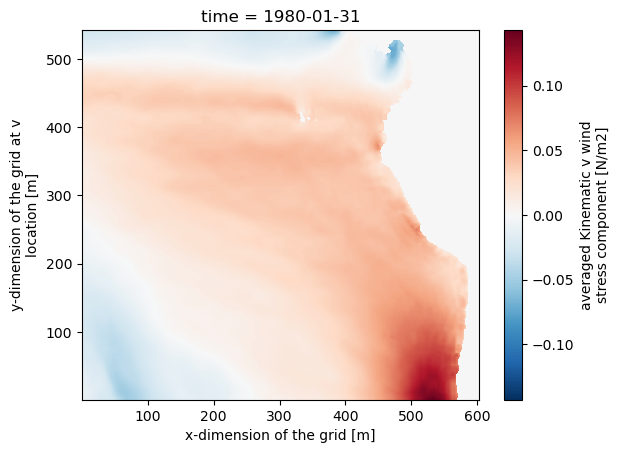

In [5]:
time = pd.date_range(start='1980-01',end='2016-01',freq='M')
ds_vwnd['time']=time
ds_uwnd['time']=time
ds_vwnd.isel(time=0).plot()

In [6]:
lon = dsi.lon_v.compute()
lat = dsi.lat_v.compute()
rho = 1025  # water density (kg/m^3)
f = dsi.f.compute()
f = f[:-1,:]
f
# dy = 111000*(lon[1]-lon[0])  # 1 degree latitude ~ 111 km

<xarray.DataArray 'f' (eta_rho: 541, xi_rho: 602)> Size: 3MB
array([[-7.94314142e-05, -7.94314142e-05, -7.94314142e-05, ...,
        -7.94314142e-05, -7.94314142e-05, -7.94314142e-05],
       [-7.92821573e-05, -7.92821573e-05, -7.92821573e-05, ...,
        -7.92821573e-05, -7.92821573e-05, -7.92821573e-05],
       [-7.91326642e-05, -7.91326642e-05, -7.91326642e-05, ...,
        -7.91326642e-05, -7.91326642e-05, -7.91326642e-05],
       ...,
       [ 2.47900302e-05,  2.47900302e-05,  2.47900302e-05, ...,
         2.47900302e-05,  2.47900302e-05,  2.47900302e-05],
       [ 2.49959950e-05,  2.49959950e-05,  2.49959950e-05, ...,
         2.49959950e-05,  2.49959950e-05,  2.49959950e-05],
       [ 2.52018574e-05,  2.52018574e-05,  2.52018574e-05, ...,
         2.52018574e-05,  2.52018574e-05,  2.52018574e-05]])
Coordinates:
  * xi_rho   (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * eta_rho  (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 538.0 539.0 540.0 541.0
    lon_rho  (eta_rho, xi_rho) float64 3MB -119.0 -118.9 ... -68.95 -68.87
    lat_rho  (eta_rho, xi_rho) float64 3MB -33.0 -33.0 -33.0 ... 9.951 9.951
Attributes:
    long_name:      Coriolis parameter at RHO-points
    units:          second-1
    field:          coriolis, scalar
    standard_name:  coriolis_parameter

In [7]:
## earth radious

a = 6378137  # equatorial radius (meters)
b = 6356752  # polar radius (meters)

# Compute the radius of curvature
r = np.sqrt(
    (a**2 * np.cos(np.deg2rad(lat)))**2 + (b**2 * np.sin(np.deg2rad(lat)))**2
) / (
    (a * np.cos(np.deg2rad(lat)))**2 + (b * np.sin(np.deg2rad(lat)))**2
)

r

<xarray.DataArray 'lat_v' (eta_v: 541, xi_rho: 602)> Size: 3MB
array([[1.00000469, 1.00000469, 1.00000469, ..., 1.00000469, 1.00000469,
        1.00000469],
       [1.00000468, 1.00000468, 1.00000468, ..., 1.00000468, 1.00000468,
        1.00000468],
       [1.00000467, 1.00000467, 1.00000467, ..., 1.00000467, 1.00000467,
        1.00000467],
       ...,
       [1.00000063, 1.00000063, 1.00000063, ..., 1.00000063, 1.00000063,
        1.00000063],
       [1.00000064, 1.00000064, 1.00000064, ..., 1.00000064, 1.00000064,
        1.00000064],
       [1.00000065, 1.00000065, 1.00000065, ..., 1.00000065, 1.00000065,
        1.00000065]])
Coordinates:
  * xi_rho   (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * eta_v    (eta_v) float64 4kB 1.5 2.5 3.5 4.5 5.5 ... 538.5 539.5 540.5 541.5
    lon_v    (eta_v, xi_rho) float64 3MB -119.0 -118.9 -118.8 ... -68.95 -68.87
    lat_v    (eta_v, xi_rho) float64 3MB -32.97 -32.97 -32.97 ... 9.992 9.992

In [10]:
f.values

array([[-7.94314142e-05, -7.94314142e-05, -7.94314142e-05, ...,
        -7.94314142e-05, -7.94314142e-05, -7.94314142e-05],
       [-7.92821573e-05, -7.92821573e-05, -7.92821573e-05, ...,
        -7.92821573e-05, -7.92821573e-05, -7.92821573e-05],
       [-7.91326642e-05, -7.91326642e-05, -7.91326642e-05, ...,
        -7.91326642e-05, -7.91326642e-05, -7.91326642e-05],
       ...,
       [ 2.47900302e-05,  2.47900302e-05,  2.47900302e-05, ...,
         2.47900302e-05,  2.47900302e-05,  2.47900302e-05],
       [ 2.49959950e-05,  2.49959950e-05,  2.49959950e-05, ...,
         2.49959950e-05,  2.49959950e-05,  2.49959950e-05],
       [ 2.52018574e-05,  2.52018574e-05,  2.52018574e-05, ...,
         2.52018574e-05,  2.52018574e-05,  2.52018574e-05]])

In [8]:
Ek_tp = ds_vwnd * (1/f.values()/rho)
Ek_tp.mean(dim='time',skipna=True).plot()

TypeError: 'numpy.ndarray' object is not callable

In [8]:
# Compute gradients of lat and lon
dlat, dlat2 = np.gradient(lat)
dlon1, dlon= np.gradient(lon)

# Calculate grid sizes in meters
dy = dlat * (r * np.pi / 180)  # Latitude spacing in meters
dx = (dlon / 180) * np.pi * r * np.cos(np.deg2rad(lat))  # Longitude spacing in meters


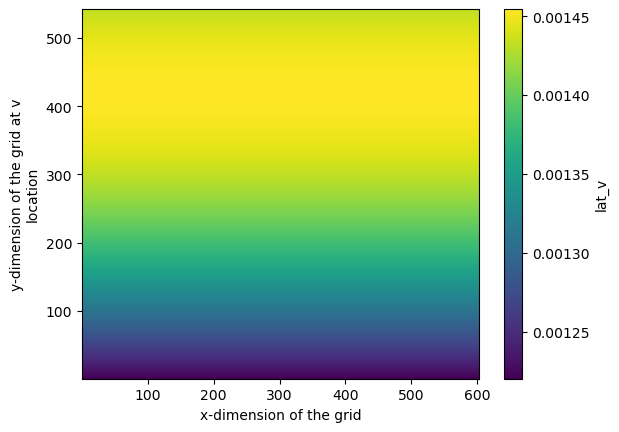

In [9]:
dx.plot()

In [69]:
print(dy.shape)
print(ds_uwnd.shape)

(541, 602)
(432, 542, 601)


In [ ]:
## let's cut 
def cut_wnds(ds, lat_min=-16, lat_max=-5, lon_min=-90, lon_max=-65):
    """
    Cut the Ekman_pump variable within the specified latitude and longitude ranges.

    Parameters:
        ds (xarray.Dataset): The input dataset containing 'Ekman_pump', 'lat', and 'lon'.
        lat_min (float): Minimum latitude (default: -16).
        lat_max (float): Maximum latitude (default: -5).
        lon_min (float): Minimum longitude (default: -90).
        lon_max (float): Maximum longitude (default: -65).

    Returns:
        xarray.DataArray: The Ekman_pump variable cut to the specified range.
    """
    # Cut the data within the specified latitude and longitude ranges
    ekman_pump_cut = ds['Ekman_pump'].where(
        (ds.lat >= lat_min) & (ds.lat <= lat_max) & 
        (ds.lon >= lon_min) & (ds.lon <= lon_max), 
        drop=True
    )
    return ekman_pump_cut

In [46]:
curl = (np.gradient(vc, dy, axis=2)-np.gradient(uc, dy, axis=1)) 
curl
# pump = curl / (rho * f)*86400

NameError: name 'vc' is not defined

In [ ]:
# rho = 1025  # water density (kg/m^3)
# omega = 7.2921e-5  # Earth's rotation rate (rad/s)
# f = 2 * omega * np.sin(latc* np.pi / 180)
# # using wind speed
# windspeed = np.sqrt(uc**2 + vc**2)
# dy = 111000*(lon[1]-lon[0])  # 1 degree latitude ~ 111 km
# epumping = rhoa * cd * windspeed * (np.gradient(vc, dy, axis=2)-np.gradient(uc, dy, axis=1)) / (rho * f)*86400
# epumping = scc / (rho * f)*86400 #using wind stress curl